----
## <font color='CornflowerBlue'>Practical 2: Constructing, Training & Evaluating Neural Networks 
##### Alok Bharadwaj and Arjen Jakobi
---

## Module 3:  Learning from graph-structured data

<!-- Pointer: Module goal:
     - Recognize when data is naturally a graph (molecules, protein contacts, networks)
     - Understand permutation symmetry as the defining constraint for graph data
     - Build a basic Graph Convolutional layer and see it work on MUTAG
     - Connect to inductive bias: GCN encodes permutation equivariance by construction
-->

### 1. What is graph data?

A graph is a data structure consisting of **nodes** (also called vertices) and **edges** that describe relationships between them.

Many real-world systems are naturally represented as graphs. For example:

| System                 | `Nodes`          | `Edges`             |
|------------------------|------------------|---------------------|
| Molecules              | atoms            | chemical bonds      |
| Protein contact maps   | amino acids      | spatial contacts    |
| Social networks        | people           | friendships         |
| Citation networks      | papers           | citations           |
| Road networks          | intersections    | roads               |

A key challenge with graph data is that its structure is **variable and irregular**: The number of nodes and edges can vary from graph to graph, here is no fixed ordering of the nodes and the connectivity pattern (which nodes are connected) can be arbitrary. This is very different from the data types (images or fixed-length vectors) you have seen so far. Interestingly, images can be viewed as a special type of graph where each pixel is a node and edges connect neighboring pixels. 

Graph Neural Networks (GNNs) generalize the idea of CNNs to arbitrary graph structures. In this sense, GNNs can be seen as a natural extension of CNNs to more general data structures.

### 2. Build a graph by hand

To build intuition for graph data, we will construct a graph manually by representing a molecule as a graph. We will use the `networkx` library, a popular Python package for creating and manipulating graphs.

In [11]:
import networkx as nx 
import numpy as np
G = nx.Graph()

Your task is to build a graph representing the *methanol molecule (CH₃OH). To translate the molecule into a graph each atom becomes a node and each chemical bond becomes an edge. For methanol we have 6 nodes [1 carbon (C), 1 oxygen (O), and 4 hydrogens (H)] and edges describing the bonds between these atoms.  



We will start by adding the atoms of the molecule as nodes in the graph. We will use the `add_node` method of the `Graph` class. Each node can store additional information through attributes, such as element type, coordinates, or charge. For now, we will only store the _element type_, using the attribute `element`.

We will represent nodes using integer identifiers (e.g. `0, 1, 2, …`) and assign the corresponding element type:
- `"C"` for carbon  
- `"O"` for oxygen  
- `"H"` for hydrogen  

After this step, your graph should contain all atoms of the methanol molecule. To use this graph in a neural network, we need to convert the element type of each node into a numerical feature vector.

We use **one-hot encoding**, where each element type is represented by a vector of length 3:
- Carbon → `[1, 0, 0]`  
- Oxygen → `[0, 1, 0]`  
- Hydrogen → `[0, 0, 1]`  

The function below implements this encoding by assigning each element type to a fixed index in the vector.

In [2]:
def one_hot_encoding_element(element_type):
    feature_vector = np.zeros(3)  # Assuming we have 3 different element types
    # you can decide which index corresponds to which element type
    index_carbon = 0
    index_oxygen = 1
    index_hydrogen = 2
    if element_type == 'C':
        feature_vector[index_carbon] = 1
    elif element_type == 'O':
        feature_vector[index_oxygen] = 1
    elif element_type == 'H':
        feature_vector[index_hydrogen] = 1
    return feature_vector

##### Your task:
Add the atoms as nodes. For each node:
- Use an integer identifier  
- Assign the correct `element`  
- Compute and assign the feature vector using `one_hot_encoding_element`  
- Store this vector in the attribute `x`  

The first node is given as an example:

```python
G.add_node(0, element="C", x=one_hot_encoding_element("C"))  # carbon


In [12]:

G.add_node(0, element="C", x = one_hot_encoding_element("C")) # for carbon
# Now add five other nodes to complete the structure of methanol (CH3OH)
G.add_node(1, element="O", x = one_hot_encoding_element("O")) # for oxygen
G.add_node(2, element="H", x = one_hot_encoding_element("H")) # for hydrogen
G.add_node(3, element="H", x = one_hot_encoding_element("H")) # for hydrogen
G.add_node(4, element="H", x = one_hot_encoding_element("H")) # for hydrogen
G.add_node(5, element="H", x = one_hot_encoding_element("H")) # for hydrogen

Now, add edges to represent the connections between the nodes. In the case of a molecule, edges correspond to chemical bonds between atoms.

We use the `add_edge` method of the `Graph` class to connect two nodes.

Edges can also store attributes, such as bond type (single, double, triple) or bond length. For now, we will keep things simple and only add the connections without any additional attributes.


In [13]:
G.add_edge(0, 1) # Connecting C-O
# Now connect the remaining nodes to form the structure of methanol
G.add_edge(1, 2) # Connecting O-H 
G.add_edge(0, 3) # Connecting C-H 
G.add_edge(0, 4) # Connecting C-H 
G.add_edge(0, 5) # Connecting C-H


To check whether your graph has been constructed correctly, it is useful to visualise it.

The function below displays the graph using `networkx`. Each node is labelled with its identifier and element type (e.g. `0:C`), and the layout is automatically arranged for clarity.

You can optionally provide a `color_map` to assign different colors to different element types (e.g. carbon, oxygen, hydrogen), which makes the structure easier to interpret visually.

Use this function to verify that:
- all nodes have been added correctly  
- the edges reflect the correct molecular structure  

In [14]:
def display_graph(G, color_map=None):
    import matplotlib.pyplot as plt
    pos = nx.spring_layout(G, seed=42)  # positions for all nodes
    labels = {node: f"{node}:{G.nodes[node]['element']}" for node in G.nodes()}
    if color_map:
        node_colors = [color_map.get(G.nodes[node]['element'], 'lightblue') for node in G.nodes()]
    else:
        node_colors = 'lightblue'
    nx.draw(G, pos, with_labels=True, labels=labels, node_color=node_colors, node_size=700)
    plt.show()

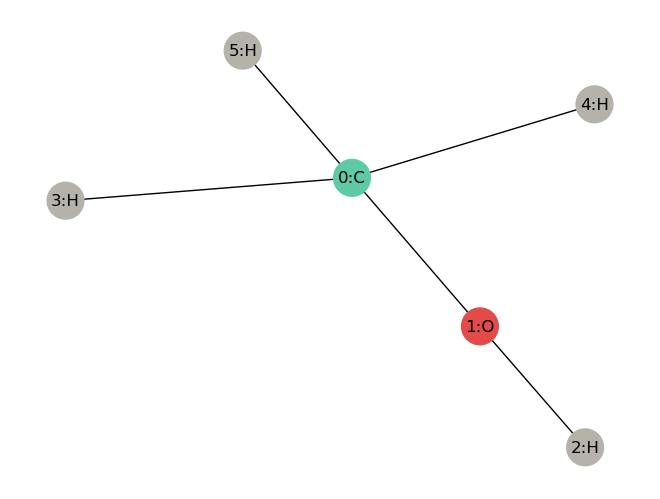

In [15]:
# Display the graph 
color_map = {"C": "#5DCAA5", "O": "#E24B4A", "H": "#B4B2A9", "N": "#378ADD"}
display_graph(G, color_map=color_map)

##### How do we represent graph data as input to a neural network? 

A graph contains two types of information: Node information (what each node represents) and connectivity information (which nodes are connected) 

We can represent these using two matrices, the **adjacency matrix** and the **node feature matrix**.

1. The **adjacency matrix** is an $N \times N$ matrix, where $N$ is the number of nodes in the graph.
   Each entry indicates whether two nodes are connected:

   - $A[i,j] = 1$ if there is an edge between node $i$ and node $j$  
   - $A[i,j] = 0$ otherwise  

   For an **undirected graph**, the adjacency matrix is symmetric, because if node $i$ is connected to node $j$, then node $j$ is also connected to node $i$.

2. The **node feature matrix** is an $N \times d$ matrix, where $d$ is the number of features for each node.

   Each row corresponds to one node, and contains its feature vector. In our molecule example, the feature vector encodes the element type of each atom using one-hot encoding.

In [16]:
# Compute the adjacency matrix 
A = nx.to_numpy_array(G, nodelist=sorted(G.nodes()))
print(A)

# Does it match the graphical relationship you defined earlier? 

[[0. 1. 0. 1. 1. 1.]
 [1. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]]


In [17]:
# Compute the node feature matrix
X = np.array([G.nodes[i]["x"] for i in sorted(G.nodes())])
print(X)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


We can combine the information about the graph structure and the node features using matrix multiplication. This is the key operation in graph neural networks, which allows us to propagate information across the graph structureaggregating features from neighbouring nodes.

One simple way to do this is to multiply the adjacency matrix $A$ with the node feature matrix $X$:

\begin{equation}
H = AX
\end{equation}

This operation produces a new matrix $H$ where:
- each row corresponds to a node  
- each row contains the **sum of the feature vectors of its neighbouring nodes**  

In other words, each node gathers information from its local neighbourhood by combining the graph structure (who is connected to whom) with the node features (what each node represents).

Compute the aggregated feature matrix $H$ for the methanol molecule by multiplying the adjacency matrix $A$ with the node feature matrix $X$.

In [18]:
aggregate_features = A @ X
print(aggregate_features)

[[0. 1. 3.]
 [1. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


Some context is helpful. In the code below, we compute the aggregated features, print the resulting matrix and examine each node individually. 

In [19]:
for i, row in enumerate(aggregate_features):
    
    element_type = G.nodes[i]["element"]
    print(f"Node {i}, Element: {element_type}, Aggregated Features: {row}")

Node 0, Element: C, Aggregated Features: [0. 1. 3.]
Node 1, Element: O, Aggregated Features: [1. 0. 1.]
Node 2, Element: H, Aggregated Features: [0. 1. 0.]
Node 3, Element: H, Aggregated Features: [1. 0. 0.]
Node 4, Element: H, Aggregated Features: [1. 0. 0.]
Node 5, Element: H, Aggregated Features: [1. 0. 0.]


Look at the output for each node: 

- Which elements appear in its aggregated feature vector? 
- Does this match the atoms it is connected to in the molecule?

This step is the foundation of message passing in graph neural networks where nodes update their representation based on their neighbours.

# Permutation equivariance 
A key property of graph data is that nodes do not have a natural ordering. This means that if we reorder (permute) the nodes, the graph still represents the same underlying structure. For example, if we relabel the nodes of the methanol molecule, the molecule itself does not change; only the indices we use to refer to the nodes.

If we change the ordering of the nodes:
- the adjacency matrix $A$ and feature matrix $X$ will change accordingly  
- however, the aggregated features should remain consistent with the new ordering 

This property is called **permutation equivariance**. Under permutation equivariance, the output changes in the same way as the input is permuted and the *structure* of the information is preserved.  

Graph neural networks are designed to satisfy this property by construction.


We can test this property by permuting the node indices and recomputing the aggregated features.

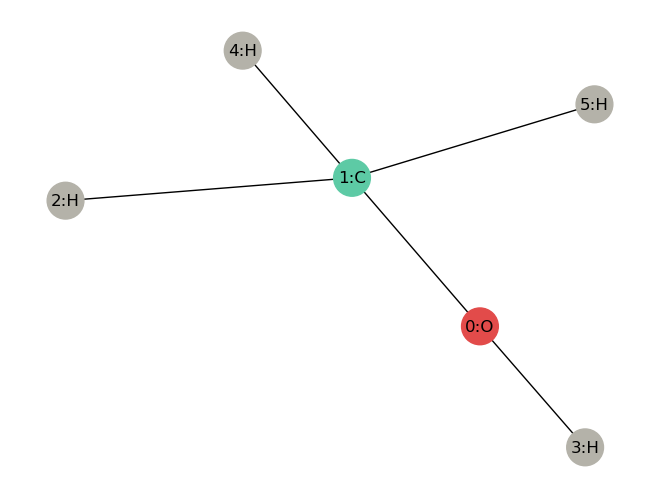

In [21]:
# Relabel the nodes in a different order and check if the aggregated features are consistent with the new node ordering
new_order = {0: 1, 1: 0, 2: 3, 3: 2, 4: 5, 5: 4}
G_permuted = nx.relabel_nodes(G, new_order)
display_graph(G_permuted, color_map=color_map)

Display the original graph and the permuted graph to confirm that they represent the same molecular structure. Although the node indices have changed, the connectivity between atoms remains the same.

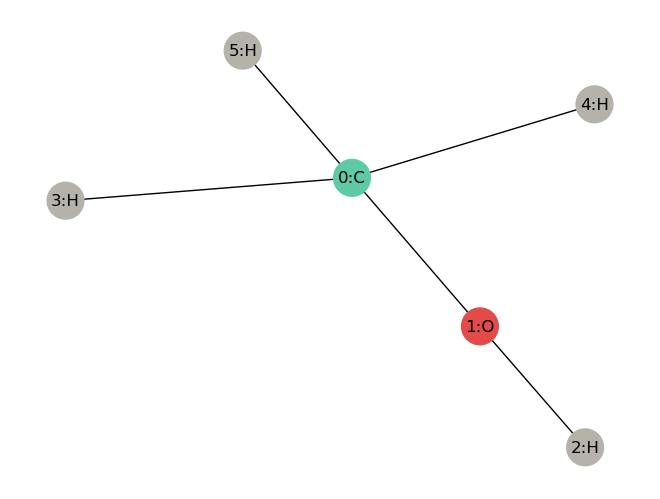

In [22]:
display_graph(G, color_map=color_map)

What happens to the aggregated information for a given atom when we permute the order of the nodes? 

Does it change? Why or why not?

💡 Think about:
- What does the aggregation $H = AX$ actually compute?
- Does this operation depend on the node labels, or only on the graph structure?

Try to compare the aggregated features before and after permutation. Are they identical, or just reordered?

In [22]:
A_permuted = nx.to_numpy_array(G_permuted, nodelist=sorted(G_permuted.nodes()))
print(A_permuted)
X_permuted = np.array([G_permuted.nodes[i]["x"] for i in sorted(G_permuted.nodes())])
print(X_permuted)


[[0. 1. 0. 1. 0. 0.]
 [1. 0. 1. 0. 1. 1.]
 [0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [23]:
aggregate_features_permuted = A_permuted @ X_permuted
for i, row in enumerate(aggregate_features_permuted):
    
    element_type = G_permuted.nodes[i]["element"]
    print(f"Node {i}, Element: {element_type}, Aggregated Features: {row}")

Node 0, Element: O, Aggregated Features: [1. 0. 1.]
Node 1, Element: C, Aggregated Features: [0. 1. 3.]
Node 2, Element: H, Aggregated Features: [1. 0. 0.]
Node 3, Element: H, Aggregated Features: [0. 1. 0.]
Node 4, Element: H, Aggregated Features: [1. 0. 0.]
Node 5, Element: H, Aggregated Features: [1. 0. 0.]


In [24]:
for i, row in enumerate(aggregate_features):
    
    element_type = G.nodes[i]["element"]
    print(f"Node {i}, Element: {element_type}, Aggregated Features: {row}")

Node 0, Element: C, Aggregated Features: [0. 1. 3.]
Node 1, Element: O, Aggregated Features: [1. 0. 1.]
Node 2, Element: H, Aggregated Features: [0. 1. 0.]
Node 3, Element: H, Aggregated Features: [1. 0. 0.]
Node 4, Element: H, Aggregated Features: [1. 0. 0.]
Node 5, Element: H, Aggregated Features: [1. 0. 0.]


##### Try it yourself: a different molecule

Can you repeat the same process for a different molecule, such as **ethanol (C₂H₅OH)**?

- Build the graph (nodes and edges)  
- Assign node features using one-hot encoding  
- Compute the adjacency matrix and feature matrix  
- Aggregate the features using $H = AX$  

What differences do you observe compared to methanol?